In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib


In [25]:
# 1. Load data

# If file is in Colab after upload:
# from google.colab import files
# uploaded = files.upload()  # then select your CSV file

# Use your file name here
#file_path = "/content/updated_dataset.csv"   # change if needed
df = pd.read_csv("/content/updated_dataset.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (16092, 15)
                         Indicator              Group          State  \
0  Symptoms of Depressive Disorder  National Estimate  United States   
1  Symptoms of Depressive Disorder             By Age  United States   
2  Symptoms of Depressive Disorder             By Age  United States   
3  Symptoms of Depressive Disorder             By Age  United States   
4  Symptoms of Depressive Disorder             By Age  United States   

        Subgroup Phase  Time Period     Time Period Label  \
0  United States   1.0            1  Apr 23 - May 5, 2020   
1  18 - 29 years   1.0            1  Apr 23 - May 5, 2020   
2  30 - 39 years   1.0            1  Apr 23 - May 5, 2020   
3  40 - 49 years   1.0            1  Apr 23 - May 5, 2020   
4  50 - 59 years   1.0            1  Apr 23 - May 5, 2020   

  Time Period Start Date Time Period End Date  Value  Low CI  High CI  \
0             04/23/2020           05/05/2020   23.5    22.7     24.3   
1             04/23/2020           

In [ ]:
# 2. Set target (label) column
# ============================================
# IMPORTANT: change this to your actual label column.
# Example: TARGET_COLUMN = "depression_label"  (0 = No, 1 = Yes)
TARGET_COLUMN = "Indicator"   # <<< CHANGE THIS

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"column not found. Change TARGET_COLUMN to your target column name.")

X = df.drop(columns=["Indicator", "target"])
y = df["Indicator"]

In [ ]:
# 3. Identify numeric and categorical columns
# ============================================
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Numeric features: ['Time Period', 'Value', 'Low CI', 'High CI']
Categorical features: ['Group', 'State', 'Subgroup', 'Phase', 'Time Period Label', 'Time Period Start Date', 'Time Period End Date', 'Confidence Interval', 'Quartile Range']


In [ ]:
# 4. Define models (Logistic Regression, Random Forest, SVM)
# ============================================
log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

rf_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

svm_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])

models = {
    "Logistic Regression": log_reg_clf,
    "Random Forest": rf_clf,
    "SVM": svm_clf
}

In [ ]:
# 5. Train-test split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class proportion same in train/test (for 0/1 labels)
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (12873, 13) Test shape: (3219, 13)


In [ ]:
# 6. Train and evaluate each model
# ============================================
results = {}

for name, model in models.items():
    print("\n==============================")
    print(f"Training: {name}")
    print("==============================")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    results[name] = {
        "model": model,
        "accuracy": acc
    }


Training: Logistic Regression
Logistic Regression Accuracy: 0.8962
Confusion Matrix:
 [[ 892   91   90]
 [  64  992   17]
 [  52   20 1001]]
Classification Report:
                                                      precision    recall  f1-score   support

                       Symptoms of Anxiety Disorder       0.88      0.83      0.86      1073
Symptoms of Anxiety Disorder or Depressive Disorder       0.90      0.92      0.91      1073
                    Symptoms of Depressive Disorder       0.90      0.93      0.92      1073

                                           accuracy                           0.90      3219
                                          macro avg       0.90      0.90      0.90      3219
                                       weighted avg       0.90      0.90      0.90      3219


Training: Random Forest
Random Forest Accuracy: 0.7863
Confusion Matrix:
 [[769 150 154]
 [142 865  66]
 [144  32 897]]
Classification Report:
                                    

In [9]:
# 7. Choose best model
# ============================================
best_model_name = max(results, key=lambda k: results[k]["accuracy"])
best_model = results[best_model_name]["model"]
best_acc = results[best_model_name]["accuracy"]

print(f"Best model: {best_model_name} (Accuracy = {best_acc:.4f})")

Best model: Logistic Regression (Accuracy = 0.8962)


In [11]:
# 8. Save best model (optional)
joblib.dump(best_model, "/content/best_anxiety_depression_model.joblib")
print("Saved best model to /content/best_anxiety_depression_model.joblib")

Saved best model to /content/best_anxiety_depression_model.joblib


In [12]:
# 9. Predict for new input (your final project requirement)
example_input = {
    # "age": 21,
    # "gender": "Female",
    # "sleep_hours": 6,
    # "physical_activity": "Low",
    # "family_history": "Yes",
    # ...
}

if example_input:
    # Convert dict to DataFrame (one row)
    new_sample = pd.DataFrame([example_input])

    # Make sure it has all columns (any missing columns will be filled with NaN)
    for col in X.columns:
        if col not in new_sample.columns:
            new_sample[col] = np.nan

    new_sample = new_sample[X.columns]  # reorder columns

    pred = best_model.predict(new_sample)[0]
    prob = best_model.predict_proba(new_sample)[0][1]  # probability of class "1" (has anxiety/depression)

    print("\nPrediction for your input:")
    print("Raw predicted class:", pred)
    if hasattr(y, "dtype") and y.dtype == "int":
        if pred == 1:
            print(f"Model output: Person is predicted to HAVE anxiety/depression (probability {prob:.2f})")
        else:
            print(f"Model output: Person is predicted to NOT have anxiety/depression (probability {prob:.2f})")
    else:
        print(f"Predicted label: {pred}, probability of positive class: {prob:.2f}")

# --- Option B: Function to predict for any input dict ---
def predict_anxiety_depression(user_input_dict):
    """
    user_input_dict: Python dict mapping feature_name -> value
                     (e.g., {"age": 22, "gender": "Male", ...})
    """
    new_df = pd.DataFrame([user_input_dict])

    for col in X.columns:
        if col not in new_df.columns:
            new_df[col] = np.nan

    new_df = new_df[X.columns]

    pred = best_model.predict(new_df)[0]
    prob = best_model.predict_proba(new_df)[0][1]

    return pred, prob

# Example usage:
# user_example = {
#     "age": 20,
#     "gender": "Male",
#     "sleep_hours": 5,
#     "physical_activity": "Low",
#     ...
# }
# pred, prob = predict_anxiety_depression(user_example)
# print("Prediction:", pred, "Probability of having anxiety/depression:", prob)

In [13]:
X_test.iloc[[0]]

,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range
2115,By Education,United States,Less than a high school diploma,1.0,11,"July 9 - July 14, 2020",07/09/2020,07/14/2020,34.9,30.1,39.9,30.1 - 39.9,NaN


In [14]:
len(X_test)

3219

In [15]:
idx = 3218  # example record index
record = X_test.iloc[[idx]]  # get the record as DataFrame (note double brackets)
actual_label = y_test.iloc[idx]
predicted_label = best_model.predict(record)[0]

print(f"Record at index {idx}:\n{record}")
print(f"Actual label: {actual_label}")
print(f"Predicted label: {predicted_label}")

Record at index 3218:
        Group       State    Subgroup Phase  Time Period  \
260  By State  New Mexico  New Mexico   1.0            2   

        Time Period Label Time Period Start Date Time Period End Date  Value  \
260  May 7 - May 12, 2020             05/07/2020           05/12/2020   29.0   

     Low CI  High CI Confidence Interval Quartile Range  
260    20.8     38.3         20.8 - 38.3    25.7 - 35.5  
Actual label: Symptoms of Depressive Disorder
Predicted label: Symptoms of Depressive Disorder


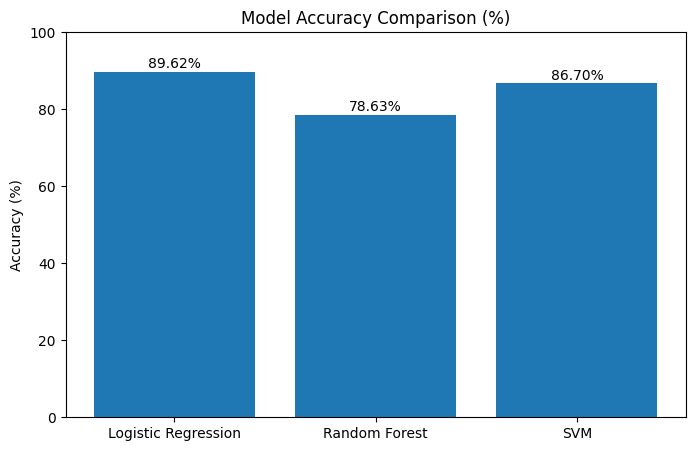

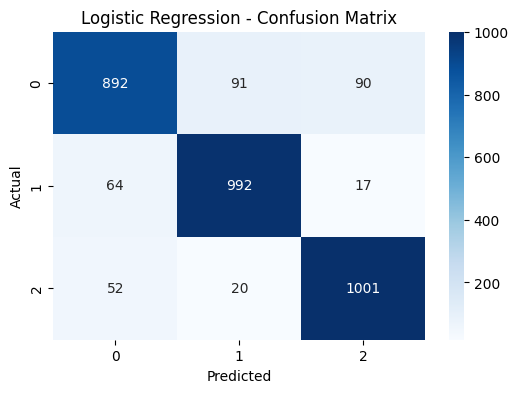

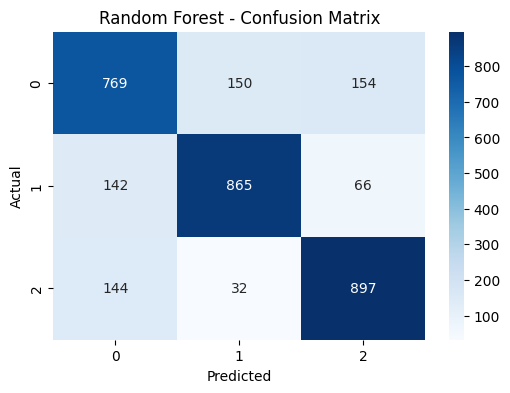

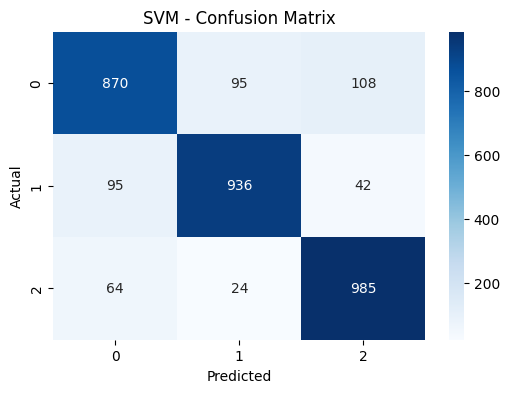

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Accuracy in percentage
model_names = ["Logistic Regression", "Random Forest", "SVM"]
accuracies = [0.8962, 0.7863, 0.8670]   # convert from decimals

accuracies_percent = [a * 100 for a in accuracies]

plt.figure(figsize=(8,5))
bars = plt.bar(model_names, accuracies_percent)
plt.title("Model Accuracy Comparison (%)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# write values on bars
for bar, acc in zip(bars, accuracies_percent):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.2f}%", ha='center')

plt.show()

# 3. Confusion Matrices
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_lr = np.array([[892, 91, 90],
                    [64, 992, 17],
                    [52, 20, 1001]])

conf_rf = np.array([[769, 150, 154],
                    [142, 865, 66],
                    [144, 32, 897]])

conf_svm = np.array([[870, 95, 108],
                     [95, 936, 42],
                     [64, 24, 985]])

cms = [conf_lr, conf_rf, conf_svm]

for name, cm in zip(model_names, cms):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [18]:
idx = 3218  # example record index
record = X_test.iloc[[idx]]  # get the record as DataFrame (note double brackets)
actual_label = y_test.iloc[idx]
predicted_label = best_model.predict(record)[0]

print(f"Record at index {idx}:\n{record}")
print(f"Actual label: {actual_label}")
print(f"Predicted label: {predicted_label}")

Record at index 3218:
        Group       State    Subgroup Phase  Time Period  \
260  By State  New Mexico  New Mexico   1.0            2   

        Time Period Label Time Period Start Date Time Period End Date  Value  \
260  May 7 - May 12, 2020             05/07/2020           05/12/2020   29.0   

     Low CI  High CI Confidence Interval Quartile Range  
260    20.8     38.3         20.8 - 38.3    25.7 - 35.5  
Actual label: Symptoms of Depressive Disorder
Predicted label: Symptoms of Depressive Disorder


In [19]:
import numpy as np
unique, count = np.unique(y, return_counts=True)
result = dict(zip(unique, count))
print(result)

{'Symptoms of Anxiety Disorder': np.int64(5364), 'Symptoms of Anxiety Disorder or Depressive Disorder': np.int64(5364), 'Symptoms of Depressive Disorder': np.int64(5364)}


In [20]:
from collections import Counter

Counter(y)

Counter({'Symptoms of Depressive Disorder': 5364,
         'Symptoms of Anxiety Disorder': 5364,
         'Symptoms of Anxiety Disorder or Depressive Disorder': 5364})

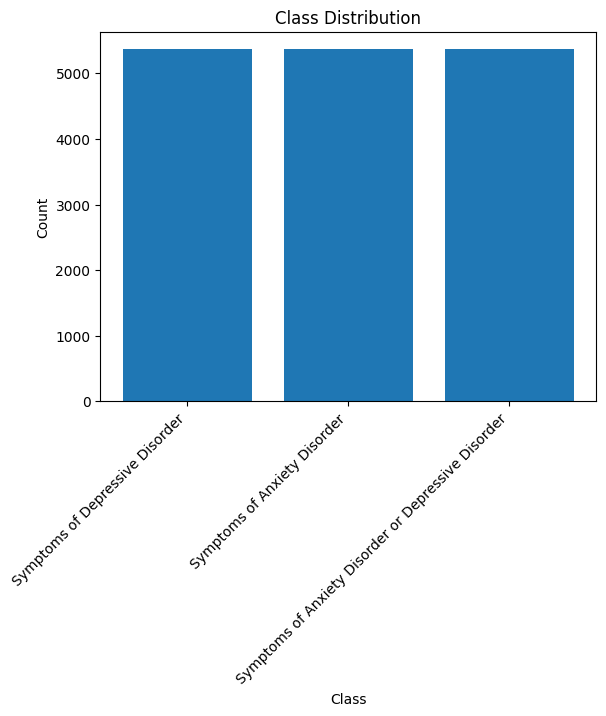

In [21]:
import matplotlib.pyplot as plt
counts = Counter(y)
plt.bar(counts.keys(), counts.values())
plt.xlabel('Class')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

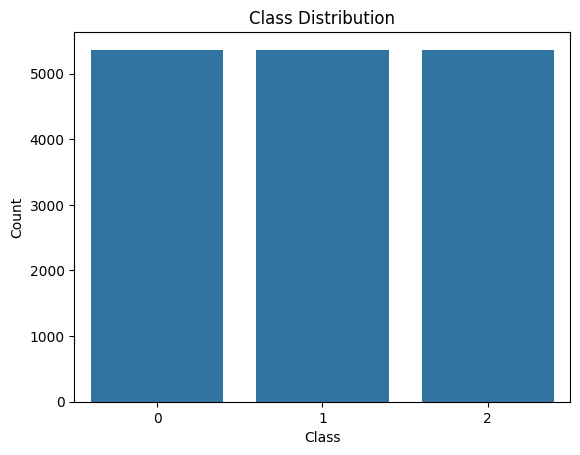

In [22]:
import seaborn as sns
short_labels = {'Symptoms of Depressive Disorder': 0,
         'Symptoms of Anxiety Disorder': 1,
         'Symptoms of Anxiety Disorder or Depressive Disorder': 2}

x = [short_labels[label] for label in y]

sns.countplot(x=x)
plt.xlabel('Class')
#plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [23]:
import pandas as pd
import numpy as np

# --------- USER INPUT SECTION ----------
print("Enter the values for prediction:\n")

group = input("Enter Group: ").strip()
state = input("Enter State: ").strip()
subgroup = input("Enter Subgroup: ").strip()
phase = input("Enter Phase: ").strip()
time_label = input("Enter Time Period Label: ").strip()

# Build single-row DataFrame
row = pd.DataFrame([{
    "Group": group,
    "State": state,
    "Subgroup": subgroup,
    "Phase": phase,
    "Time Period Label": time_label
}])

# Ensure all expected model columns exist
for col in X.columns:
    if col not in row.columns:
        row[col] = np.nan

# Reorder columns to match training order
new_df = row[X.columns]

# label map from model classes
label_map = {i: label for i, label in enumerate(best_model.classes_)}

# Predict
pred = best_model.predict(new_df)[0]
probs = best_model.predict_proba(new_df)[0]

# Index of predicted class
predicted_class_index = int(np.where(best_model.classes_ == pred)[0][0])

result = {
    "Prediction Code": predicted_class_index,
    "Prediction Label": str(pred),
    "Probabilities": {str(best_model.classes_[i]): float(probs[i]) for i in range(len(probs))}
}

# Output result
print("\n===== Prediction Result =====")
print("Prediction:", result["Prediction Label"])
print("Prediction Code:", result["Prediction Code"])
print("\nClass Probabilities:")
for k, v in result["Probabilities"].items():
    print(f"{k}: {v:.4f}")


Enter the values for prediction:

Enter Group: By Age
Enter State: United States
Enter Subgroup: 18 - 29 years
Enter Phase: 1
Enter Time Period Label: 1

===== Prediction Result =====
Prediction: Symptoms of Depressive Disorder
Prediction Code: 2

Class Probabilities:
Symptoms of Anxiety Disorder: 0.0557
Symptoms of Anxiety Disorder or Depressive Disorder: 0.0017
Symptoms of Depressive Disorder: 0.9426
